In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [13]:
df = pd.read_csv("RIPAoc2020.csv", low_memory=False)

# should be all OC
df["AGENCY_NAME"].value_counts().head()

AGENCY_NAME
ORANGE CO SO    39855
Name: count, dtype: int64

In [14]:
df["DATE_OF_STOP"] = pd.to_datetime(df["DATE_OF_STOP"], errors="coerce")
df["STOP_DURATION"] = pd.to_numeric(df["STOP_DURATION"], errors="coerce")
df["AGE"] = pd.to_numeric(df["AGE"], errors="coerce")

/var/folders/4n/gr221w3n74g83smf7w9pzfy00000gn/T/ipykernel_7476/2096568016.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATE_OF_STOP"] = pd.to_datetime(df["DATE_OF_STOP"], errors="coerce")


In [17]:
df_2020 = df[df["DATE_OF_STOP"].dt.year == 2020].copy()
df_2020["AGENCY_NAME"].value_counts().head(10)

AGENCY_NAME
ORANGE CO SO    39855
Name: count, dtype: int64

In [18]:
df_2020["STOP_DURATION"].describe()

count    39855.000000
mean        20.040146
std         43.433863
min          1.000000
25%          5.000000
50%         10.000000
75%         15.000000
max       1440.000000
Name: STOP_DURATION, dtype: float64

In [19]:
df_2020["AGE"].describe()

count    39855.000000
mean        37.326960
std         13.759071
min          1.000000
25%         25.000000
50%         35.000000
75%         45.000000
max        100.000000
Name: AGE, dtype: float64

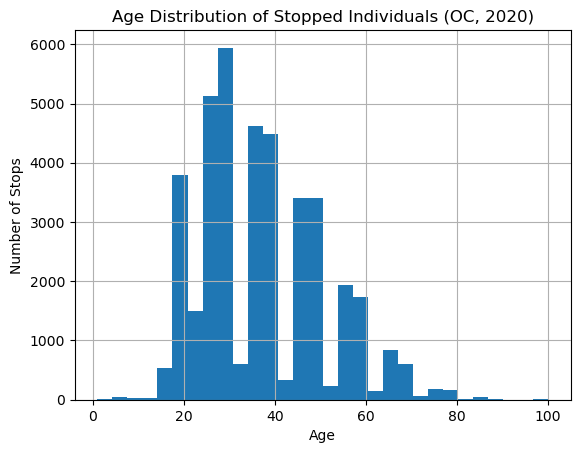

In [20]:
plt.figure()
df_2020["AGE"].dropna().hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Stops")
plt.title("Age Distribution of Stopped Individuals (OC, 2020)")
plt.show()

In [21]:
race_cols = [
    "RAE_ASIAN",
    "RAE_BLACK_AFRICAN_AMERICAN",
    "RAE_HISPANIC_LATINO",
    "RAE_WHITE",
    "RAE_NATIVE_AMERICAN",
    "RAE_PACIFIC_ISLANDER",
    "RAE_MIDDLE_EASTERN_SOUTH_ASIAN",
    "RAE_MULTIRACIAL"
]

race_counts = df_2020[race_cols].sum().sort_values(ascending=False)
race_counts

RAE_WHITE                         19423
RAE_HISPANIC_LATINO               13756
RAE_ASIAN                          2576
RAE_MIDDLE_EASTERN_SOUTH_ASIAN     2123
RAE_BLACK_AFRICAN_AMERICAN         1637
RAE_NATIVE_AMERICAN                 504
RAE_PACIFIC_ISLANDER                265
RAE_MULTIRACIAL                     217
dtype: int64

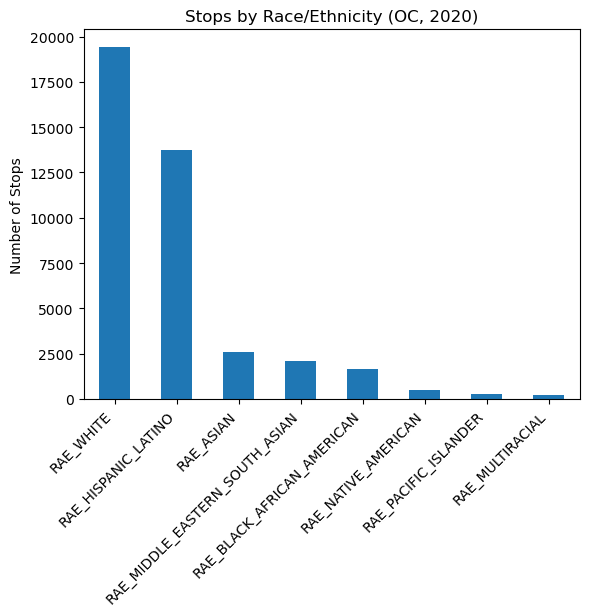

In [22]:
plt.figure()
race_counts.plot(kind="bar")
plt.ylabel("Number of Stops")
plt.title("Stops by Race/Ethnicity (OC, 2020)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [23]:
gender_cols = [
    "G_MALE",
    "G_FEMALE",
    "G_TRANSGENDER_MAN",
    "G_TRANSGENDER_WOMAN",
    "G_GENDER_NONCONFORMING",
    "G_MULTIGENDER"
]

gender_counts = df_2020[gender_cols].sum()
gender_counts

G_MALE                    27608
G_FEMALE                  11751
G_TRANSGENDER_MAN            45
G_TRANSGENDER_WOMAN          17
G_GENDER_NONCONFORMING      437
G_MULTIGENDER                 3
dtype: int64

In [24]:
df_2020["REASON_FOR_STOP"].value_counts()

REASON_FOR_STOP
1    31085
2     3983
6     2262
3     1959
4      344
5      218
7        3
8        1
Name: count, dtype: int64

In [25]:
df_2020["ADS_HANDCUFFED"].value_counts(normalize=True)

ADS_HANDCUFFED
0    0.94214
1    0.05786
Name: proportion, dtype: float64

In [27]:
outcome_cols = [
    "ROS_WARNING",
    "ROS_CITATION",
    "ROS_CUSTODIAL_WITHOUT_WARRANT",
    "ROS_CUSTODIAL_WARRANT",
    "ROS_NO_ACTION"
]

df_2020[outcome_cols].sum().sort_values(ascending=False)

ROS_CITATION                     17617
ROS_WARNING                       9851
ROS_NO_ACTION                     7430
ROS_CUSTODIAL_WITHOUT_WARRANT     1580
ROS_CUSTODIAL_WARRANT              773
dtype: int64

In [ ]:
# We look at searches of person and property
df_2020["ANY_SEARCH"] = (
    (df_2020["ADS_SEARCH_PERSON"] == 1) |
    (df_2020["ADS_SEARCH_PROPERTY"] == 1)
)

In [30]:
# Hispanic vs. White
def search_rate(df, race_col):
    return df.loc[df[race_col] == 1, "ANY_SEARCH"].mean()

search_rates = {
    "Hispanic/Latino": search_rate(df_2020, "RAE_HISPANIC_LATINO"),
    "White": search_rate(df_2020, "RAE_WHITE")
}
search_rates

{'Hispanic/Latino': np.float64(0.27180866530968306),
 'White': np.float64(0.20810379447047314)}